# Direct Acoustic vs. Multi-Hop Optical Link Benchmark

This notebook automates comprehensive parameter sweeps comparing a single-hop acoustic underwater baseline against multi-hop optical links (ordinary optical and optical with beam pattern/LUT) across:
- **Total Distance** (20 m to 100 m)
- **Relay Count (Expanding Distance)** (1 to 4 relay couples, 51 m to 129 m)
- **Offered Traffic** (CBR period from 0.005 s to 1.0 s, Poisson traffic)
- **Packet Size** (64 to 500 bytes)
- **Water Turbidity / Attenuation Sweep (Test 1)** ($c$ from 0.1 m$^{-1}$ to 2.0 m$^{-1}$)
- **Relay Count at Fixed Distance (Test 4)** (1 to 5 relays to span 100 m)

Evaluated metrics include **End-to-End PDR**, **Goodput**, **Mean Delay**, **Energy Consumption per Delivered Bit (Test 3)** ($\mu$J/bit), and **Weakest Optical Hop PDR**. Statistical significance is evaluated using **30 repetitions** per configuration across independent random streams, computing **95% Student's t confidence intervals**, and plotting them with classic single error bars for each data point.

In [33]:
import concurrent.futures
import math
import os
import re
import shlex
import statistics
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Output parser regexes
SENT_RE = re.compile(r"sent packets:\s*([0-9]+(?:\.[0-9]+)?)")
RECEIVED_RE = re.compile(r"received packets:\s*([0-9]+(?:\.[0-9]+)?)")
FTT_RE = re.compile(r"forward trip time mean:\s*([-+0-9.eE]+)")
FTT_STD_RE = re.compile(r"forward trip time std:\s*([-+0-9.eE]+)")
MAC_RE = re.compile(
    r"^\s*modem\s+(\d+):\s+([0-9.eE+-]+)\s+([0-9.eE+-]+)",
    re.MULTILINE,
)
print("Imports and regex parsers ready.")


Imports and regex parsers ready.


### 1. Environment and Path Configuration
Set up paths for DESERT environment source script, TCL models, and logging directories.

In [34]:
NOTEBOOK_DIR = Path(".").resolve()
REPO_ROOT = NOTEBOOK_DIR.parents[5] if len(NOTEBOOK_DIR.parents) >= 5 else NOTEBOOK_DIR

ENV_PATH = REPO_ROOT / "DESERT_buildCopy_LOCAL" / "environment"
OPTICAL_SIM = NOTEBOOK_DIR / "multi_hop_optical_tdma.tcl"
BEAM_SIM = NOTEBOOK_DIR / "multi_hop_optical_tdma_beampattern.tcl"
ACOUSTIC_SIM = NOTEBOOK_DIR / "single_link_comp.tcl"

OUTPUT_DIR = NOTEBOOK_DIR / "optical_acoustic_comparison_results"
LOGS_DIR = OUTPUT_DIR / "logs"
LOGS_DIR.mkdir(parents=True, exist_ok=True)

REPETITIONS = 30
print(f"Results output path: {OUTPUT_DIR}")
print(f"Repetitions per configuration: {REPETITIONS}")


Results output path: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results
Repetitions per configuration: 30


### 2. Simulation Execution Function
Encapsulates shell invocation under `zsh -lc`, collects stdout/stderr, and extracts metrics.

In [35]:
def optical_hop_length(total_distance: float, n_relays: int, relay_gap: float) -> float:
    length = (total_distance - n_relays * relay_gap) / (n_relays + 1)
    if length <= 0:
        raise ValueError("Total distance is too short for the requested relay gaps.")
    return length


def run_case(environment: Path, simulation: Path, workdir: Path, log_path: Path,
             *, technology: str, n_relays: int, total_distance: float,
             cbr_period: float, packet_size: int, depth: float,
             stop_time: float, rngstream: int, relay_gap: float,
             attenuation_scale: float, poisson_traffic: int,
             optical_txpower: float, optical_threshold: float,
             optical_theta: float) -> dict:
    is_optical = technology != "acoustic"
    hop_length = optical_hop_length(total_distance, n_relays, relay_gap)
    values = [
        n_relays, cbr_period, packet_size,
        hop_length if is_optical else total_distance,
        relay_gap, depth, stop_time, rngstream, attenuation_scale, poisson_traffic
    ]
    if is_optical:
        values.extend(["", optical_txpower, optical_threshold, optical_theta])
    command = "source {env} && ns {simulation} {args}".format(
        env=shlex.quote(str(environment.resolve())),
        simulation=shlex.quote(str(simulation.resolve())),
        args=" ".join(shlex.quote(str(v)) for v in values),
    )
    completed = subprocess.run(
        ["zsh", "-lc", command], cwd=workdir, text=True, capture_output=True, check=False
    )
    output = completed.stdout + completed.stderr
    log_path.write_text(output, encoding="utf-8")
    
    if completed.returncode != 0:
        raise RuntimeError(f"Simulation failed; check {log_path}")

    sent_match = SENT_RE.search(output)
    received_match = RECEIVED_RE.search(output)
    if sent_match is None or received_match is None:
        raise RuntimeError(f"Could not parse packet counters; check {log_path}")
    sent = float(sent_match.group(1))
    received = float(received_match.group(1))
    ftt_match = FTT_RE.search(output)
    ftt_std_match = FTT_STD_RE.search(output)

    mac = {}
    hop_pdrs = []
    if is_optical:
        mac = {int(node): (float(s), float(r)) for node, s, r in MAC_RE.findall(output)}
        for hop in range(n_relays + 1):
            transmitted = mac.get(hop, (0.0, 0.0))[0]
            received_hop = mac.get(hop + 1, (0.0, 0.0))[1]
            hop_pdrs.append(received_hop / transmitted if transmitted else math.nan)
    finite_hops = [v for v in hop_pdrs if math.isfinite(v)]

    # Energy modeling (Test 3): 10.0 W electrical transmit power
    p_tx_electrical = 10.0
    bitrate = 1000000.0 if is_optical else 20768.0
    packet_tx_duration = packet_size * 8.0 / bitrate
    total_tx_packets = sum(s for s, _ in mac.values()) if is_optical else sent
    total_tx_energy_j = total_tx_packets * p_tx_electrical * packet_tx_duration
    delivered_bits = received * packet_size * 8.0
    tx_energy_per_bit_uj = (total_tx_energy_j / delivered_bits * 1e6) if delivered_bits > 0 else math.nan

    return {
        "technology": technology,
        "n_relays": n_relays,
        "hop_count": n_relays + 1 if is_optical else 1,
        "total_distance": total_distance,
        "hop_length": hop_length if is_optical else total_distance,
        "sent_packets": sent,
        "received_packets": received,
        "pdr": received / sent if sent else math.nan,
        "goodput_bps": received * packet_size * 8.0 / stop_time,
        "delay_mean_s": float(ftt_match.group(1)) if ftt_match else math.nan,
        "delay_std_s": float(ftt_std_match.group(1)) if ftt_std_match else math.nan,
        "tx_energy_per_bit_uj": tx_energy_per_bit_uj,
        "mean_hop_pdr": statistics.mean(finite_hops) if finite_hops else math.nan,
        "weakest_hop_pdr": min(finite_hops) if finite_hops else math.nan,
    }

### 3. Generate Full Sweep Cases
Includes all 4 parameter sweeps active simultaneously (distance, relays, offered traffic, packet size).

In [36]:
import yaml
with open("./multi_hop_optical_tdma_opt.yaml") as params:
    params_yaml = yaml.load(params, Loader=yaml.SafeLoader)
common = {
    "cbr_period": 0.25,
    "packet_size": 125,
    "depth": params_yaml['opt']['depth'],
    "stop_time": params_yaml['opt']['stoptime'],
    "relay_gap": params_yaml['opt']['relay_gap'],
    "attenuation_scale": params_yaml['opt']['attenuation_scale'],
    "poisson_traffic": params_yaml['opt']['poisson_traffic'],
    "optical_txpower": params_yaml['opt']['txpower'],
    "optical_threshold": params_yaml['opt']['acq_threshold_db'],
    "optical_theta": params_yaml['opt']['theta'],
}
cases = []
def add(sweep: str, value: float, n_relays: int, technologies: tuple, **overrides) -> None:
    base = dict(common)
    base.update({"n_relays": n_relays, "total_distance": 50.0})
    base.update(overrides)
    for technology in technologies:
        for repetition in range(1, REPETITIONS + 1):
            case = dict(base)
            case.update({
                "sweep": sweep,
                "sweep_value": value,
                "technology": technology,
                "rngstream": repetition,
            })
            cases.append(case)

# 1. Total distance sweep
for distance in (20.0, 40.0, 60.0, 80.0, 100.0):
    add("total_distance", distance, 2, ("acoustic", "optical", "beam_optical"), total_distance=distance)

# 2. Relay count sweep: expanding chain distance (25m hops)
base_hop_length = 25.0
for n_relays in (1, 2, 3, 4):
    tot_dist = (n_relays + 1) * base_hop_length + n_relays * common["relay_gap"]
    add("relay_count", float(n_relays), n_relays, ("acoustic", "optical", "beam_optical"), total_distance=tot_dist)

# 3. Traffic interval sweep (Poisson)
for period in (0.005, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0):
    add("offered_traffic", period, 2, ("acoustic", "optical", "beam_optical"), cbr_period=period, poisson_traffic=1)

# 4. Packet size sweep
for packet_size in (64, 125, 250, 500):
    add("packet_size", float(packet_size), 2, ("acoustic", "optical", "beam_optical"), packet_size=packet_size)

# 5. Test 1: Water Turbidity / Attenuation sweep (c in m^-1)
for c_val in (0.1, 0.3, 0.5, 0.8, 1.2, 1.6, 2.0):
    scale_factor = c_val / 0.3
    add("water_turbidity", float(c_val), 2, ("acoustic", "optical", "beam_optical"), total_distance=50.0, attenuation_scale=scale_factor)

# 6. Test 4: Relays to span a fixed 100 m target distance
for n_relays in (1, 2, 3, 4, 5):
    add("relays_fixed_100m", float(n_relays), n_relays, ("acoustic", "optical", "beam_optical"), total_distance=100.0)

print(f"Total experiment runs scheduled: {len(cases)}")

Total experiment runs scheduled: 2250


In [37]:
print(f"Total scheduled cases: {len(cases)}")
print("Sample configuration (first case):")
print(cases[0])


Total scheduled cases: 2250
Sample configuration (first case):
{'cbr_period': 0.25, 'packet_size': 125, 'depth': -10.0, 'stop_time': 1000.0, 'relay_gap': 1.0, 'attenuation_scale': 1.0, 'poisson_traffic': 1, 'optical_txpower': 10.0, 'optical_threshold': 15.0, 'optical_theta': 0.524, 'n_relays': 2, 'total_distance': 20.0, 'sweep': 'total_distance', 'sweep_value': 20.0, 'technology': 'acoustic', 'rngstream': 1}


### 4. Execute Simulation Suite
Executes all cases, parses log files, and persists raw observations to `results.csv`.

In [38]:
sim_map = {
    "acoustic": ACOUSTIC_SIM,
    "optical": OPTICAL_SIM,
    "beam_optical": BEAM_SIM,
}

def execute_case(idx_case):
    idx, case = idx_case
    tech = str(case["technology"])
    sim_file = sim_map[tech]
    log_path = LOGS_DIR / f"{idx:04d}_{tech}_{case['sweep']}_{case['sweep_value']}_rep{case['rngstream']:02d}.log"
    result = run_case(
        ENV_PATH,
        sim_file,
        sim_file.parent,
        log_path,
        **{
            k: case[k]
            for k in (
                "technology",
                "n_relays",
                "total_distance",
                "cbr_period",
                "packet_size",
                "depth",
                "stop_time",
                "rngstream",
                "relay_gap",
                "attenuation_scale",
                "poisson_traffic",
                "optical_txpower",
                "optical_threshold",
                "optical_theta",
            )
        },
    )
    result.update({
        "sweep": case["sweep"],
        "sweep_value": case["sweep_value"],
        "rngstream": case["rngstream"],
    })
    return idx, result

max_workers = os.cpu_count() or 4
print(f"Executing {len(cases)} simulation runs using {max_workers} parallel workers...")

results_dict = {}
total_cases = len(cases)
completed_count = 0

with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(execute_case, (idx, case)): idx
        for idx, case in enumerate(cases, 1)
    }
    for future in concurrent.futures.as_completed(futures):
        idx, res = future.result()
        results_dict[idx] = res
        completed_count += 1
        if completed_count % 50 == 0 or completed_count == total_cases:
            pct = (completed_count / total_cases) * 100
            print(f"Progress: [{completed_count:04d}/{total_cases:04d}] ({pct:.1f}%) completed")

rows = [results_dict[i] for i in sorted(results_dict.keys())]
df_results = pd.DataFrame(rows)
df_results.to_csv(OUTPUT_DIR / "results.csv", index=False)
print("Runs complete. Raw data exported to results.csv")
df_results.head()


Executing 2250 simulation runs using 16 parallel workers...
Progress: [0050/2250] (2.2%) completed
Progress: [0100/2250] (4.4%) completed
Progress: [0150/2250] (6.7%) completed
Progress: [0200/2250] (8.9%) completed
Progress: [0250/2250] (11.1%) completed
Progress: [0300/2250] (13.3%) completed
Progress: [0350/2250] (15.6%) completed
Progress: [0400/2250] (17.8%) completed
Progress: [0450/2250] (20.0%) completed
Progress: [0500/2250] (22.2%) completed
Progress: [0550/2250] (24.4%) completed
Progress: [0600/2250] (26.7%) completed
Progress: [0650/2250] (28.9%) completed
Progress: [0700/2250] (31.1%) completed
Progress: [0750/2250] (33.3%) completed
Progress: [0800/2250] (35.6%) completed
Progress: [0850/2250] (37.8%) completed
Progress: [0900/2250] (40.0%) completed
Progress: [0950/2250] (42.2%) completed
Progress: [1000/2250] (44.4%) completed
Progress: [1050/2250] (46.7%) completed
Progress: [1100/2250] (48.9%) completed
Progress: [1150/2250] (51.1%) completed
Progress: [1200/2250] (5

,technology,n_relays,hop_count,total_distance,hop_length,sent_packets,received_packets,pdr,goodput_bps,delay_mean_s,delay_std_s,mean_hop_pdr,weakest_hop_pdr,sweep,sweep_value,rngstream
0,acoustic,2,1,20.0,20.0,3842.0,3842.0,1.0,3842.0,0.088726,0.030370,NaN,NaN,total_distance,20.0,1
1,acoustic,2,1,20.0,20.0,3921.0,3921.0,1.0,3921.0,0.088947,0.030509,NaN,NaN,total_distance,20.0,2
2,acoustic,2,1,20.0,20.0,3849.0,3849.0,1.0,3849.0,0.088455,0.029783,NaN,NaN,total_distance,20.0,3
3,acoustic,2,1,20.0,20.0,3972.0,3972.0,1.0,3972.0,0.089226,0.030087,NaN,NaN,total_distance,20.0,4
4,acoustic,2,1,20.0,20.0,3973.0,3973.0,1.0,3973.0,0.088346,0.029232,NaN,NaN,total_distance,20.0,5


metrics = [
    "pdr",
    "goodput_bps",
    "delay_mean_s",
    "tx_energy_per_bit_uj",
    "mean_hop_pdr",
    "weakest_hop_pdr",
]
agg_spec = {m: ["mean", "std", ("ci95", ci95)] for m in metrics}
df_summary = (
    df_results.groupby(["technology", "sweep", "sweep_value"], as_index=False)
    .agg(agg_spec)
)
df_summary.columns = [
    f"{c[0]}_{c[1]}".strip("_") if c[1] else c[0] for c in df_summary.columns
]
rep_counts = (
    df_results.groupby(["technology", "sweep", "sweep_value"])["rngstream"]
    .count()
    .reset_index(name="repetitions")
)
df_summary = pd.merge(rep_counts, df_summary, on=["technology", "sweep", "sweep_value"])
df_summary = df_summary.fillna(0.0)
df_summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
print("Summary statistics computed with 95% Student's t confidence intervals.")
df_summary.head(10)

In [39]:
import math
# Critical values for two-tailed Student's t-distribution at alpha=0.05 (95% CI)
T_CRIT_95 = {
    1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262,
    10: 2.228, 11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131, 16: 2.120, 17: 2.110,
    18: 2.101, 19: 2.093, 20: 2.086, 21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
    26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042, 40: 2.021, 50: 2.009, 60: 2.000, 100: 1.984
}

def get_t_crit_95(df: int) -> float:
    if df in T_CRIT_95:
        return T_CRIT_95[df]
    if df <= 1:
        return 12.706
    if df >= 100:
        return 1.960
    keys = sorted(T_CRIT_95.keys())
    for i in range(len(keys) - 1):
        if keys[i] <= df <= keys[i + 1]:
            x0, x1 = keys[i], keys[i + 1]
            y0, y1 = T_CRIT_95[x0], T_CRIT_95[x1]
            return y0 + (y1 - y0) * (df - x0) / (x1 - x0)
    return 1.960

def ci95(series: pd.Series) -> float:
    """Computes the half-width margin of error of the 95% Student's t confidence interval."""
    s = series.dropna()
    n = len(s)
    if n <= 1:
        return 0.0
    val_std = s.std(ddof=1)
    if math.isnan(val_std) or val_std == 0:
        return 0.0
    return get_t_crit_95(n - 1) * val_std / math.sqrt(n)

metrics = [
    "pdr",
    "goodput_bps",
    "delay_mean_s",
    "mean_hop_pdr",
    "weakest_hop_pdr",
]
agg_spec = {m: ["mean", "std", ("ci95", ci95)] for m in metrics}

df_summary = (
    df_results.groupby(["technology", "sweep", "sweep_value"], as_index=False)
    .agg(agg_spec)
)
df_summary.columns = [
    f"{c[0]}_{c[1]}".strip("_") if c[1] else c[0] for c in df_summary.columns
]
# Compute count of repetitions
rep_counts = (
    df_results.groupby(["technology", "sweep", "sweep_value"])["rngstream"]
    .count()
    .reset_index(name="repetitions")
)
df_summary = pd.merge(rep_counts, df_summary, on=["technology", "sweep", "sweep_value"])
df_summary = df_summary.fillna(0.0)
df_summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
print("Summary table with 95% confidence intervals created.")
df_summary.head(10)


Summary table with 95% confidence intervals created.


,technology,sweep,sweep_value,repetitions,pdr_mean,pdr_std,pdr_ci95,goodput_bps_mean,goodput_bps_std,goodput_bps_ci95,delay_mean_s_mean,delay_mean_s_std,delay_mean_s_ci95,mean_hop_pdr_mean,mean_hop_pdr_std,mean_hop_pdr_ci95,weakest_hop_pdr_mean,weakest_hop_pdr_std,weakest_hop_pdr_ci95
0,acoustic,offered_traffic,0.005,30,0.026025,0.000160,0.000060,5199.366667,21.840303,8.154388,4.144390,0.000360,0.000135,0.0,0.0,0.0,0.0,0.0,0.0
1,acoustic,offered_traffic,0.010,30,0.103475,0.000723,0.000270,10332.000000,40.792156,15.230331,4.151745,0.000345,0.000129,0.0,0.0,0.0,0.0,0.0,0.0
2,acoustic,offered_traffic,0.020,30,0.313595,0.001721,0.000643,15640.833333,0.461133,0.172171,4.143564,0.000576,0.000215,0.0,0.0,0.0,0.0,0.0,0.0
3,acoustic,offered_traffic,0.050,30,0.783379,0.006593,0.002461,15639.300000,2.321563,0.866789,4.014514,0.010646,0.003975,0.0,0.0,0.0,0.0,0.0,0.0
4,acoustic,offered_traffic,0.100,30,1.000000,0.000000,0.000000,10001.533333,94.571897,35.309762,0.156201,0.002335,0.000872,0.0,0.0,0.0,0.0,0.0,0.0
5,acoustic,offered_traffic,0.250,30,1.000000,0.000000,0.000000,3998.133333,70.644683,26.376196,0.109022,0.000598,0.000223,0.0,0.0,0.0,0.0,0.0,0.0
6,acoustic,offered_traffic,0.500,30,1.000000,0.000000,0.000000,1987.566667,49.529986,18.492724,0.102099,0.000577,0.000215,0.0,0.0,0.0,0.0,0.0,0.0
7,acoustic,offered_traffic,1.000,30,1.000000,0.000000,0.000000,999.066667,32.455735,12.117810,0.099328,0.000652,0.000243,0.0,0.0,0.0,0.0,0.0,0.0
8,acoustic,packet_size,64.000,30,1.000000,0.000000,0.000000,2045.969067,36.965985,13.801776,0.073855,0.000273,0.000102,0.0,0.0,0.0,0.0,0.0,0.0
9,acoustic,packet_size,125.000,30,1.000000,0.000000,0.000000,3998.133333,70.644683,26.376196,0.109022,0.000598,0.000223,0.0,0.0,0.0,0.0,0.0,0.0


### 6. Plotting Results
Generates 1x4 subplots for each of the 4 sweep experiments (PDR, Goodput, Mean Delay, Weakest Optical-Hop PDR) with classic 95% confidence interval error bars per data point and saves figures to disk.

Saved plot: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_total_distance.png


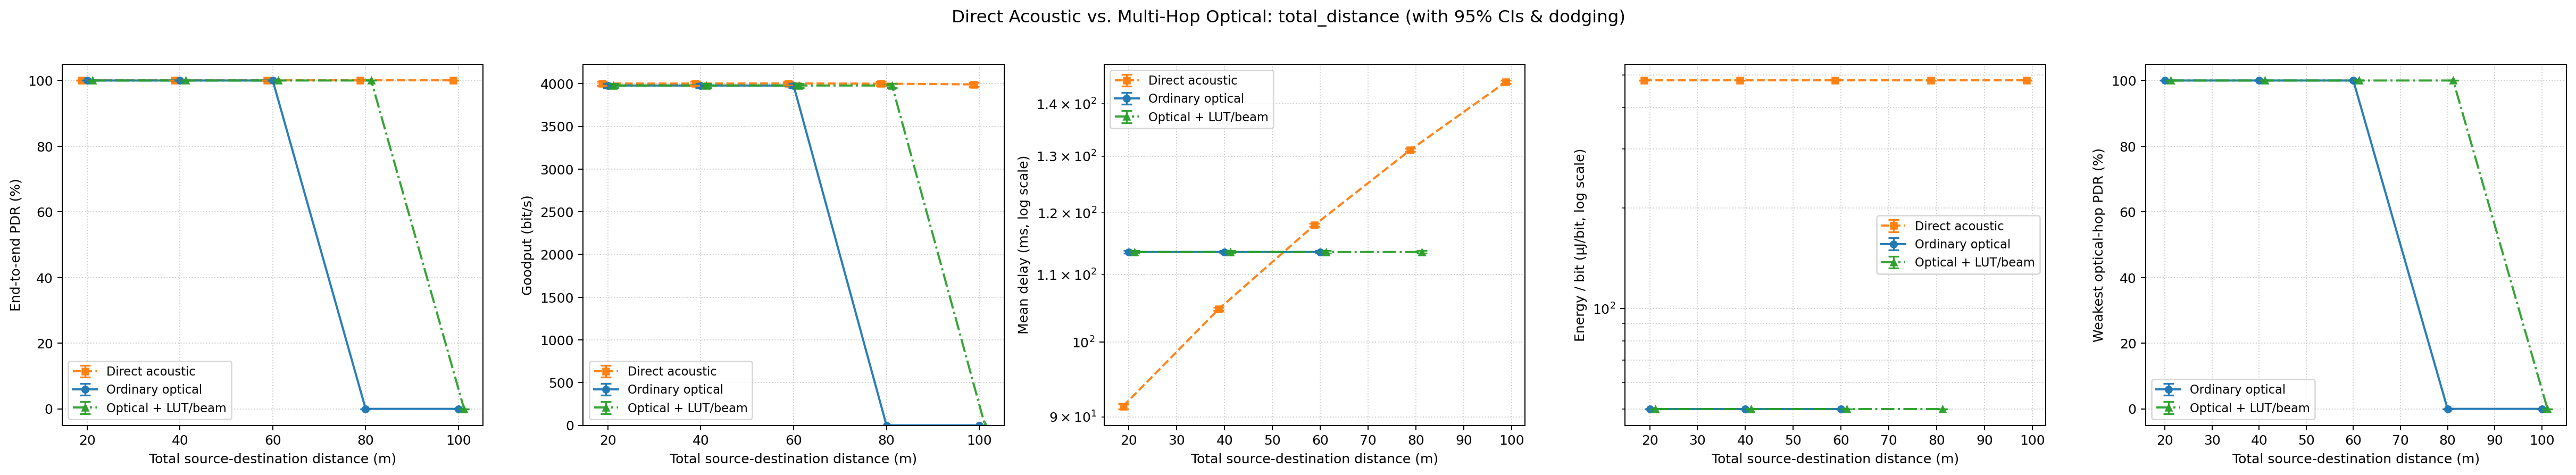

Saved plot: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_relay_count.png


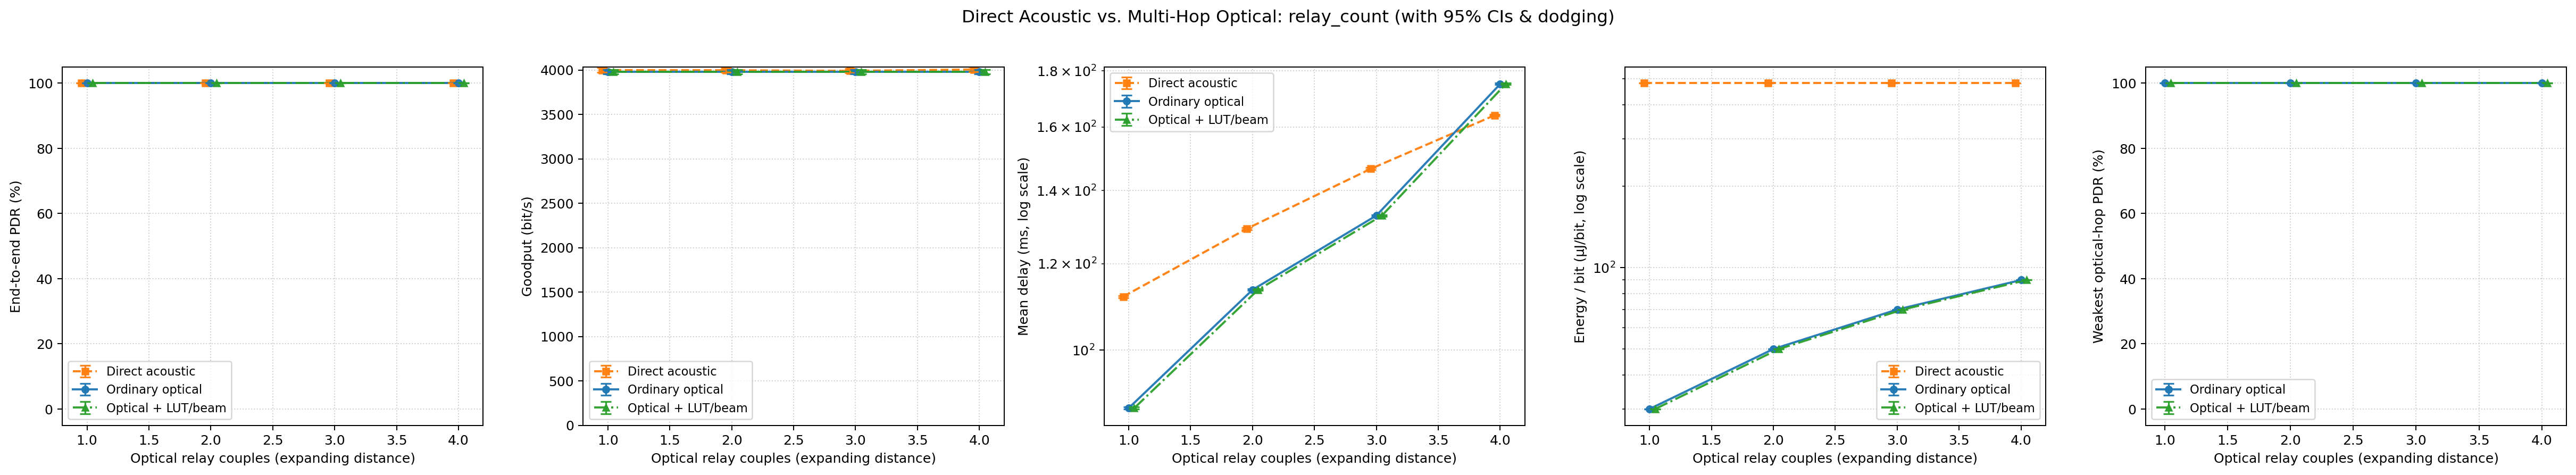

Saved plot: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_offered_traffic.png


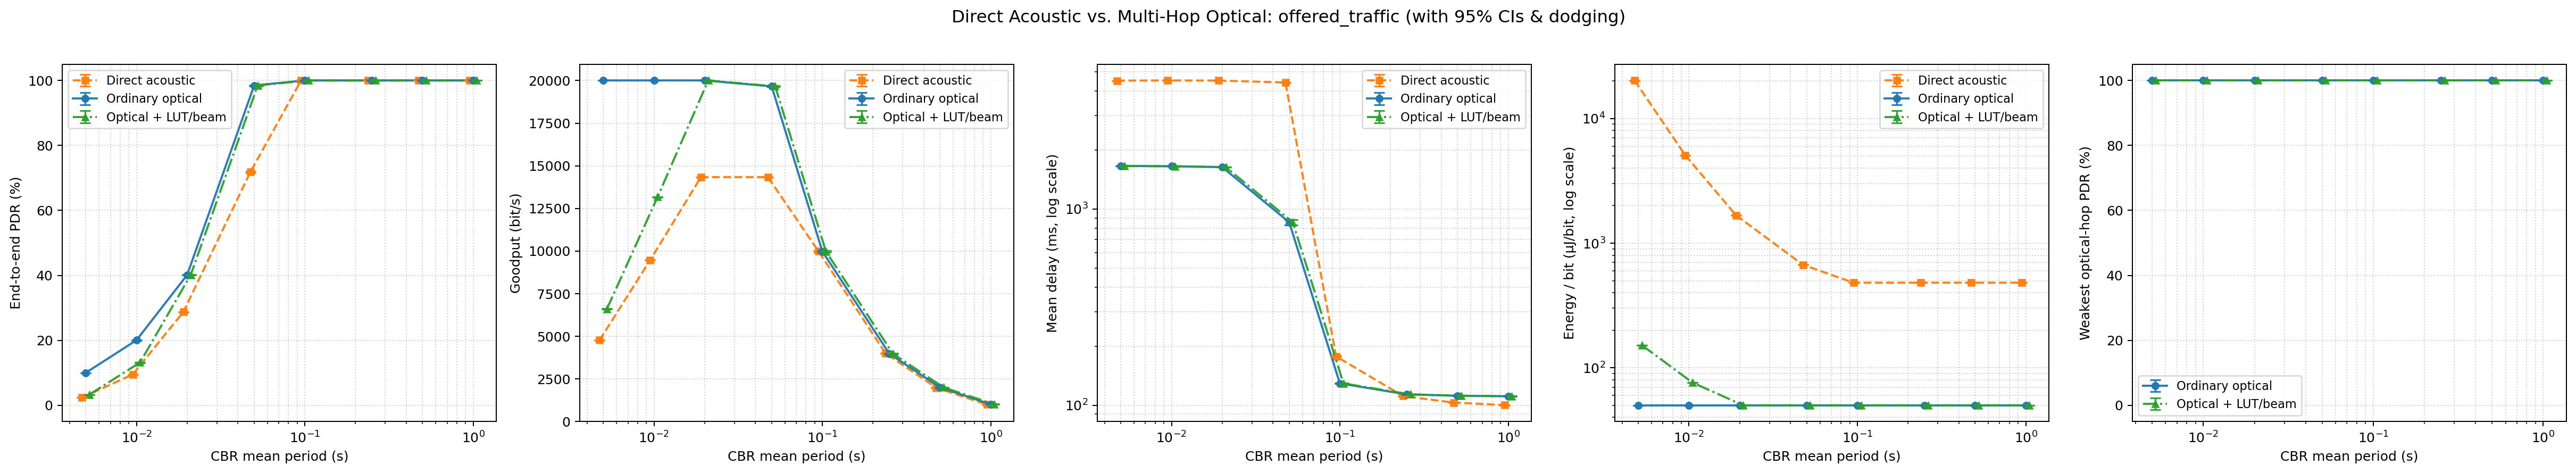

Saved plot: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_packet_size.png


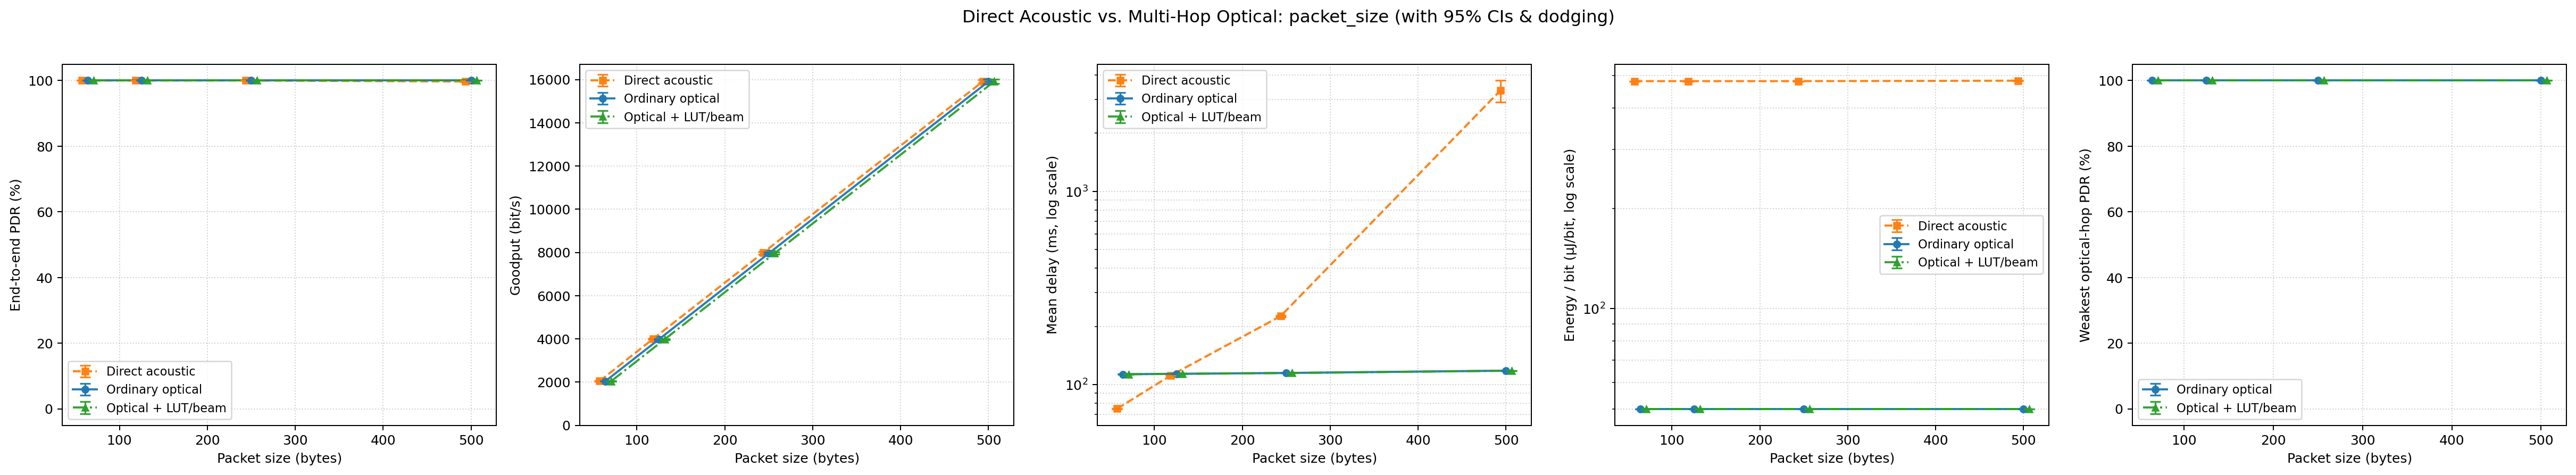

Saved plot: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_water_turbidity.png


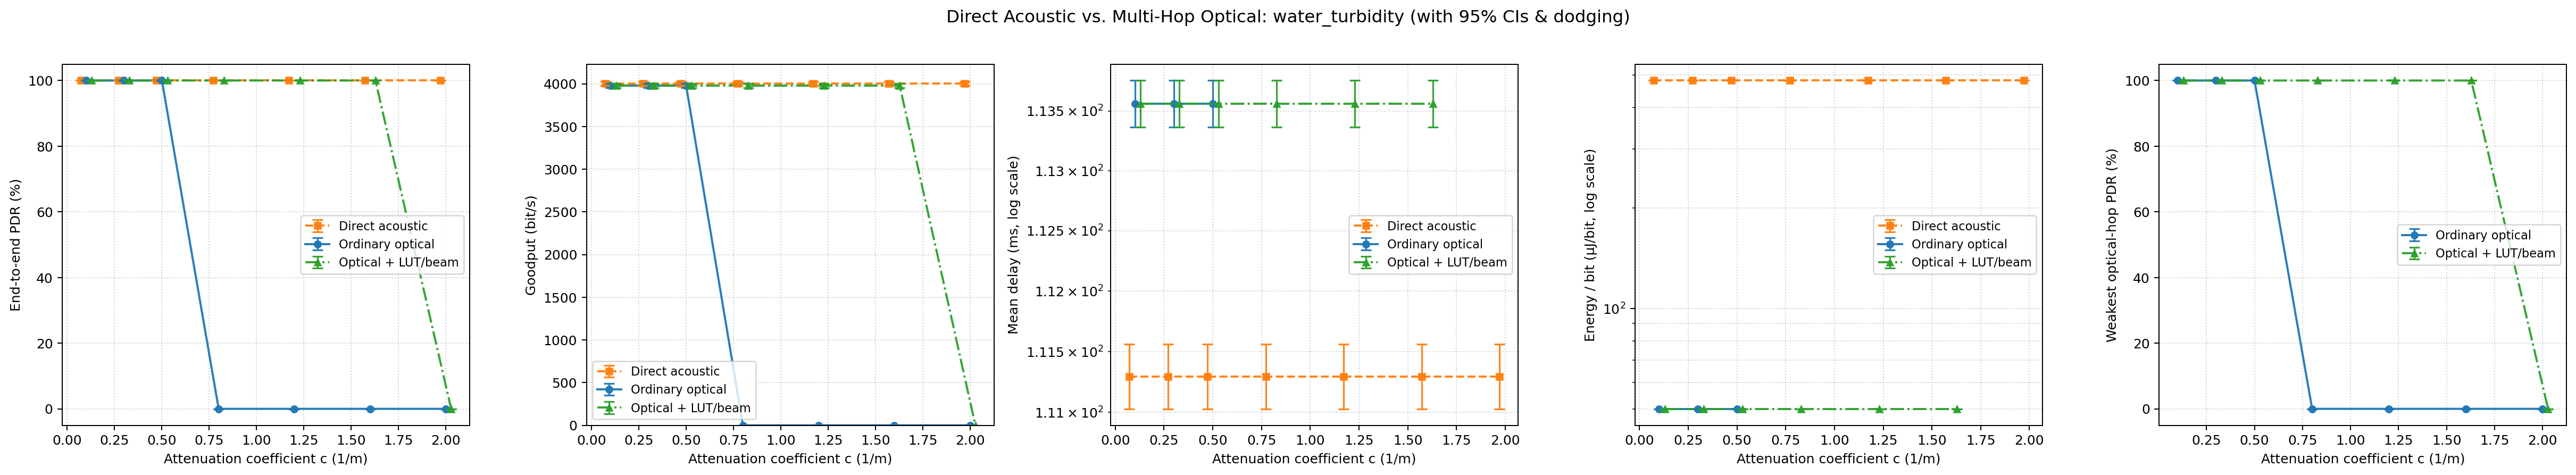

Saved plot: /home/pietro/DESERT_Underwater/DESERT_Framework/DESERT/samples/desert_samples/Channel/Optical/optical_acoustic_comparison_results/comparison_relays_fixed_100m.png


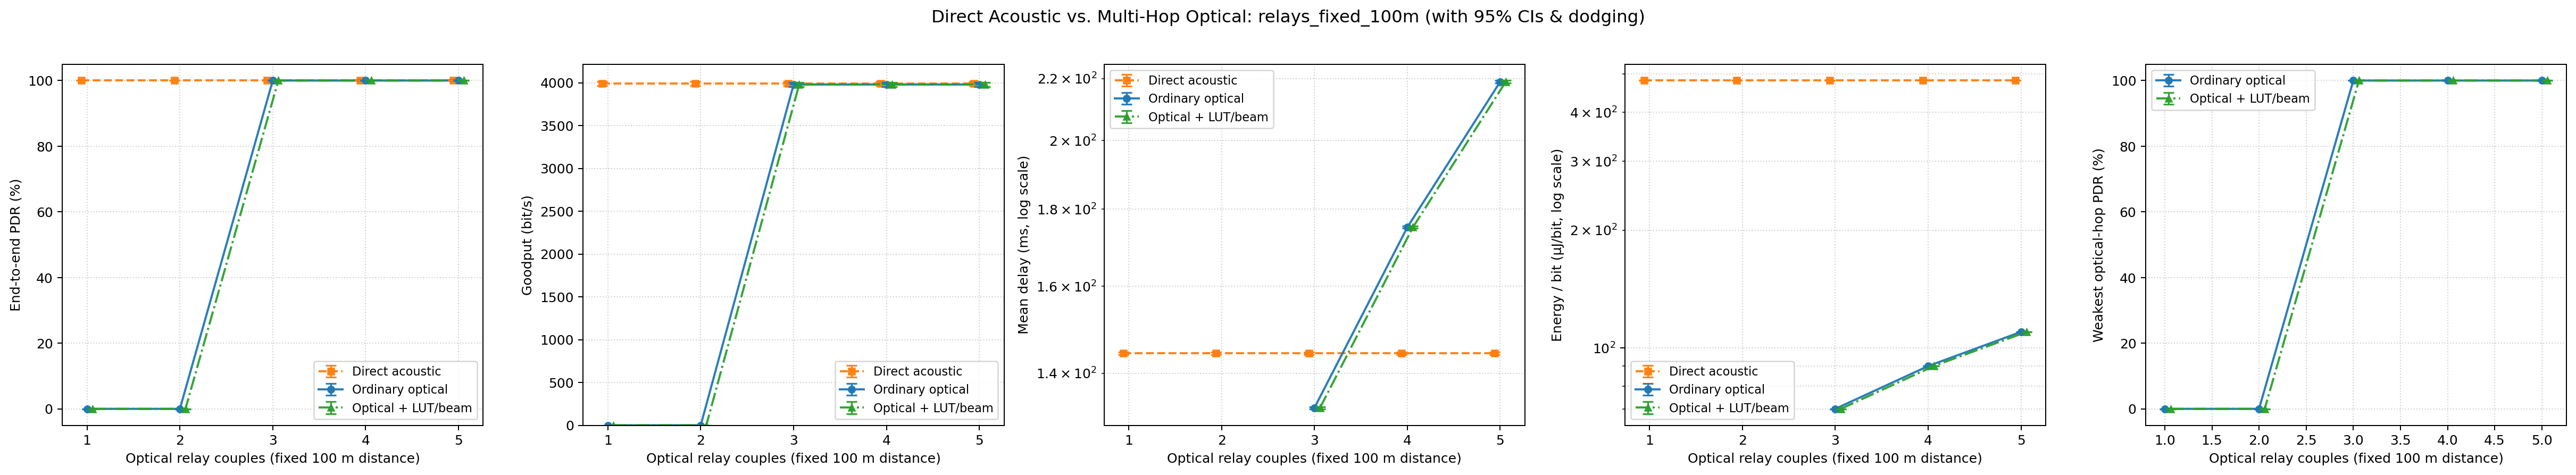

In [40]:
colors = {
    "acoustic": "tab:orange",
    "optical": "tab:blue",
    "beam_optical": "tab:green",
}
labels = {
    "acoustic": "Direct acoustic",
    "optical": "Ordinary optical",
    "beam_optical": "Optical + LUT/beam",
}
styles = {
    "acoustic": ("s", "--"),
    "optical": ("o", "-"),
    "beam_optical": ("^", "-."),
}
definitions = {
    "total_distance": "Total source-destination distance (m)",
    "relay_count": "Optical relay couples (expanding distance)",
    "offered_traffic": "CBR mean period (s)",
    "packet_size": "Packet size (bytes)",
    "water_turbidity": "Attenuation coefficient c (1/m)",
    "relays_fixed_100m": "Optical relay couples (fixed 100 m distance)",
}

for sweep, xlabel in definitions.items():
    selected = df_summary[df_summary["sweep"] == sweep].copy()
    if selected.empty:
        continue

    fig, axes = plt.subplots(1, 5, figsize=(27, 4.8), dpi=120)

    vals = np.sort(selected["sweep_value"].unique().astype(float))
    is_log_x = (sweep == "offered_traffic")
    span = vals[-1] - vals[0] if len(vals) > 1 else 1.0

    dodge_linear = {
        "acoustic": -0.015 * span,
        "optical": 0.0,
        "beam_optical": 0.015 * span,
    }
    dodge_log = {
        "acoustic": 0.95,
        "optical": 1.0,
        "beam_optical": 1.05,
    }

    for technology in ("acoustic", "optical", "beam_optical"):
        pts = selected[selected["technology"] == technology].sort_values("sweep_value")
        if pts.empty:
            continue
        raw_x = pts["sweep_value"].astype(float).values
        if is_log_x:
            x = raw_x * dodge_log[technology]
        else:
            x = raw_x + dodge_linear[technology]

        marker, linestyle = styles[technology]
        color = colors[technology]
        label = labels[technology]
        fmt = marker + linestyle

        err_kwargs = {
            "fmt": fmt,
            "color": color,
            "label": label,
            "linewidth": 1.6,
            "markersize": 5.0,
            "capsize": 4,
            "capthick": 1.3,
            "elinewidth": 1.3,
            "barsabove": True,
            "alpha": 0.95,
        }

        # 1. End-to-end PDR (%)
        y0 = 100.0 * pts["pdr_mean"].values
        ci0 = 100.0 * pts["pdr_ci95"].values
        axes[0].errorbar(x, y0, yerr=ci0, **err_kwargs)

        # 2. Goodput (bit/s)
        y1 = pts["goodput_bps_mean"].values
        ci1 = pts["goodput_bps_ci95"].values
        axes[1].errorbar(x, y1, yerr=ci1, **err_kwargs)

        # 3. Mean delay (ms)
        y2 = 1000.0 * pts["delay_mean_s_mean"].values
        ci2 = 1000.0 * pts["delay_mean_s_ci95"].values
        valid_delay = y2 > 0
        if np.any(valid_delay):
            axes[2].errorbar(x[valid_delay], y2[valid_delay], yerr=ci2[valid_delay], **err_kwargs)

        # 4. Energy per delivered bit (uJ/bit) - Test 3
        y_energy = pts["tx_energy_per_bit_uj_mean"].values
        ci_energy = pts["tx_energy_per_bit_uj_ci95"].values
        valid_energy = (y_energy > 0) & (pts["pdr_mean"].values > 0)
        if np.any(valid_energy):
            axes[3].errorbar(x[valid_energy], y_energy[valid_energy], yerr=ci_energy[valid_energy], **err_kwargs)

        # 5. Weakest optical-hop PDR (%)
        if technology != "acoustic":
            y4 = 100.0 * pts["weakest_hop_pdr_mean"].values
            ci4 = 100.0 * pts["weakest_hop_pdr_ci95"].values
            axes[4].errorbar(x, y4, yerr=ci4, **err_kwargs)

    axes[0].set_ylabel("End-to-end PDR (%)")
    axes[0].set_ylim(-5, 105)
    axes[1].set_ylabel("Goodput (bit/s)")
    axes[1].set_ylim(bottom=0)
    axes[2].set_ylabel("Mean delay (ms, log scale)")
    axes[2].set_yscale("log")
    axes[3].set_ylabel("Energy / bit (\u03bcJ/bit, log scale)")
    axes[3].set_yscale("log")
    axes[4].set_ylabel("Weakest optical-hop PDR (%)")
    axes[4].set_ylim(-5, 105)

    for ax in axes:
        ax.set_xlabel(xlabel)
        if is_log_x:
            ax.set_xscale("log")
        ax.grid(True, linestyle=":", alpha=0.6, which="both")
        ax.legend(frameon=True, fontsize=9)

    fig.suptitle(f"Direct Acoustic vs. Multi-Hop Optical: {sweep} (with 95% CIs & dodging)", fontsize=13, y=1.02)
    fig.tight_layout()
    save_path = OUTPUT_DIR / f"comparison_{sweep}.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print(f"Saved plot: {save_path}")
    plt.show()
